In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Add paths
code_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/code'
sys.path.insert(0, code_path)
sys.path.insert(0, os.path.join(code_path, 'Script'))

from Sklearn_Regression_models import RegressionModels

print("\u2714'Setup complete!")

✔'Setup complete!


## **Initialize Trainer (Loads Data)**

In [3]:
# Update this path to my CSV location
file_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/archive/car_prices.csv'

# Create trainer instance (automatically loads and preprocesses data)
trainer = RegressionModels(file_path)

print("\n'U=2705' Trainer initialized! Data is ready.")

REGRESSION MODELS TRAINING

Ὄ2 Loading preprocessed data...
✅ Loaded 558,837 rows and 16 columns

STEP 1: CLEANING DATA
✅ Dropped columns: ['vin']
✅ Cleaned transmission column - fixed invalid values
⚠️ Dropped saledate (could not parse)

STEP 2: HANDLING MISSING VALUES
Missing values found: {'make': np.int64(10301), 'model': np.int64(10399), 'trim': np.int64(10651), 'body': np.int64(13195), 'condition': np.int64(11820), 'odometer': np.int64(94), 'color': np.int64(749), 'interior': np.int64(749), 'mmr': np.int64(38), 'sellingprice': np.int64(12)}
✅ Filled transmission missing values with 'automatic'
✅ Filled make missing values with mode: 'Ford'
✅ Filled model missing values with mode: 'Altima'
✅ Filled trim missing values with mode: 'Base'
✅ Filled body missing values with mode: 'Sedan'
✅ Filled color missing values with mode: 'black'
✅ Filled interior missing values with mode: 'black'
✅ Filled condition missing values with median: 35.00
✅ Filled odometer missing values with median: 5

## **Train Linear Regression**

In [8]:
model_lr, metrics_lr = trainer.train_linear_regression()


 Training Linear Regression

   Ὄ8 Results:
   Training R²: 0.8486
   Test R²: 0.8489
   Test MAE: $0.28
   Test RMSE: $0.43
   Test MAPE: 28.33%
   Training time: 0.29 seconds
   ὋE Model saved: linear_regression.pkl
   ὍD Predictions saved: linear_regression_predictions.csv


## **Train Ridge Regression**

In [9]:
model_ridge, metrics_ridge = trainer.train_ridge(alpha=1.0)


 Training Ridge Regression (alpha=1.0)

   Ὄ8 Results:
   Training R²: 0.8486
   Test R²: 0.8489
   Test MAE: $0.28
   Test RMSE: $0.43
   Test MAPE: 28.33%
   Training time: 0.11 seconds
   ὋE Model saved: ridge_regression.pkl
   ὍD Predictions saved: ridge_predictions.csv


## **Train Lasso Regression**

In [10]:
model_lasso, metrics_lasso = trainer.train_lasso(alpha=1.0)


📈 Training Lasso Regression (alpha=1.0)

   Ὄ8 Results:
   Training R²: 0.0000
   Test R²: -0.0000
   Test MAE: $0.98
   Test RMSE: $1.50
   Test MAPE: 132.17%
   Training time: 0.94 seconds
   ὋE Model saved: lasso_regression.pkl
   ὍD Predictions saved: lasso_predictions.csv


## **Train ElasticNet**

In [11]:
model_en, metrics_en = trainer.train_elasticnet(alpha=1.0, l1_ratio=0.5)


 Training ElasticNet (alpha=1.0, l1_ratio=0.5)

   Ὄ8 Results:
   Training R²: 0.3694
   Test R²: 0.3706
   Test MAE: $0.70
   Test RMSE: $1.07
   Test MAPE: 90.12%
   Training time: 0.51 seconds
   ὋE Model saved: elasticnet_regression.pkl
   ὍD Predictions saved: elasticnet_predictions.csv


## **Train Bayesian Ridge**

In [12]:
model_br, metrics_br = trainer.train_bayesian_ridge()


 Training Bayesian Ridge Regressor

   Ὄ8 Results:
   Training R²: 0.8486
   Test R²: 0.8489
   Test MAE: $0.28
   Test RMSE: $0.43
   Test MAPE: 28.33%
   Training time: 0.45 seconds
   ὋE Model saved: bayesian_ridge.pkl
   ὍD Predictions saved: bayesian_ridge_predictions.csv


## **Train Decision Tree**

In [13]:
model_dt, metrics_dt = trainer.train_decision_tree(max_depth=20)


 Training Decision Tree Regressor (max_depth=20)

   Ὄ8 Results:
   Training R²: 0.9823
   Test R²: 0.9155
   Test MAE: $0.15
   Test RMSE: $0.31
   Test MAPE: 15.41%
   Training time: 5.87 seconds
   ὋE Model saved: decision_tree_regressor.pkl
   ὍD Predictions saved: decision_tree_predictions.csv

   Ὄ8 Top 10 Most Important Features:
      mmr: 0.9422
      condition: 0.0184
      odometer: 0.0090
      seller_encoded: 0.0084
      model_encoded: 0.0043
      trim_encoded: 0.0035
      state_encoded: 0.0034
      year: 0.0029
      make_encoded: 0.0024
      color_encoded: 0.0020
   ὌA Feature importance saved: decision_tree_feature_importance.csv


## **Train Random Forest**

In [15]:
model_rf, metrics_rf = trainer.train_random_forest(n_estimators=100)


 Training Random Forest Regressor (n_estimators=100)

   Ὄ8 Results:
   Training R²: 0.9929
   Test R²: 0.9500
   Test MAE: $0.12
   Test RMSE: $0.23
   Test MAPE: 12.51%
   Training time: 184.75 seconds
   ὋE Model saved: random_forest_regressor.pkl
   ὍD Predictions saved: random_forest_predictions.csv

   Ὄ8 Top 10 Most Important Features:
      mmr: 0.9272
      condition: 0.0185
      odometer: 0.0112
      seller_encoded: 0.0108
      model_encoded: 0.0059
      state_encoded: 0.0050
      trim_encoded: 0.0050
      year: 0.0039
      make_encoded: 0.0035
      color_encoded: 0.0032
   ὌA Feature importance saved: random_forest_feature_importance.csv


## **Train KNN Regressor**

In [14]:
model_knn, metrics_knn = trainer.train_knn_regressor(n_neighbors=5)


 Training K-Neighbors Regressor (k=5)

   Ὄ8 Results:
   Training R²: 0.9407
   Test R²: 0.9110
   Test MAE: $0.17
   Test RMSE: $0.31
   Test MAPE: 18.39%
   Training time: 0.07 seconds
   ὋE Model saved: knn_regressor.pkl
   ὍD Predictions saved: knn_regressor_predictions.csv


## **Compare Models**

In [16]:
results_df = trainer.save_all_results()

print("\n" + "="*60)
print(" FINAL MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))


 MODEL COMPARISON SUMMARY
                       Model  Train R²       Test R²  Test MAE ($)  Test RMSE ($)  Test MAPE (%)  Training Time (s)
       Random Forest (n=100)  0.992950  9.499733e-01      0.122463       0.227628      12.507544         184.754491
Decision Tree (max_depth=20)  0.982252  9.155187e-01      0.151870       0.305399      15.414803           5.865947
         KNN Regressor (k=5)  0.940660  9.109942e-01      0.174071       0.314626      18.388611           0.074044
              Bayesian Ridge  0.848573  8.488544e-01      0.275027       0.428285      28.325263           0.448786
Ridge Regression (alpha=1.0)  0.848573  8.488542e-01      0.275029       0.428285      28.325192           0.106242
           Linear Regression  0.848573  8.488542e-01      0.275029       0.428285      28.325184           0.292060
      ElasticNet (alpha=1.0)  0.369410  3.705872e-01      0.697530       1.069780      90.122889           0.513416
Lasso Regression (alpha=1.0)  0.000000 -8.228

## **Plot Actual vs Predicted (Best Model)**

   Best Model: Random Forest (n=100)
   Test R²: 0.9500
   Test MAPE: 12.51%


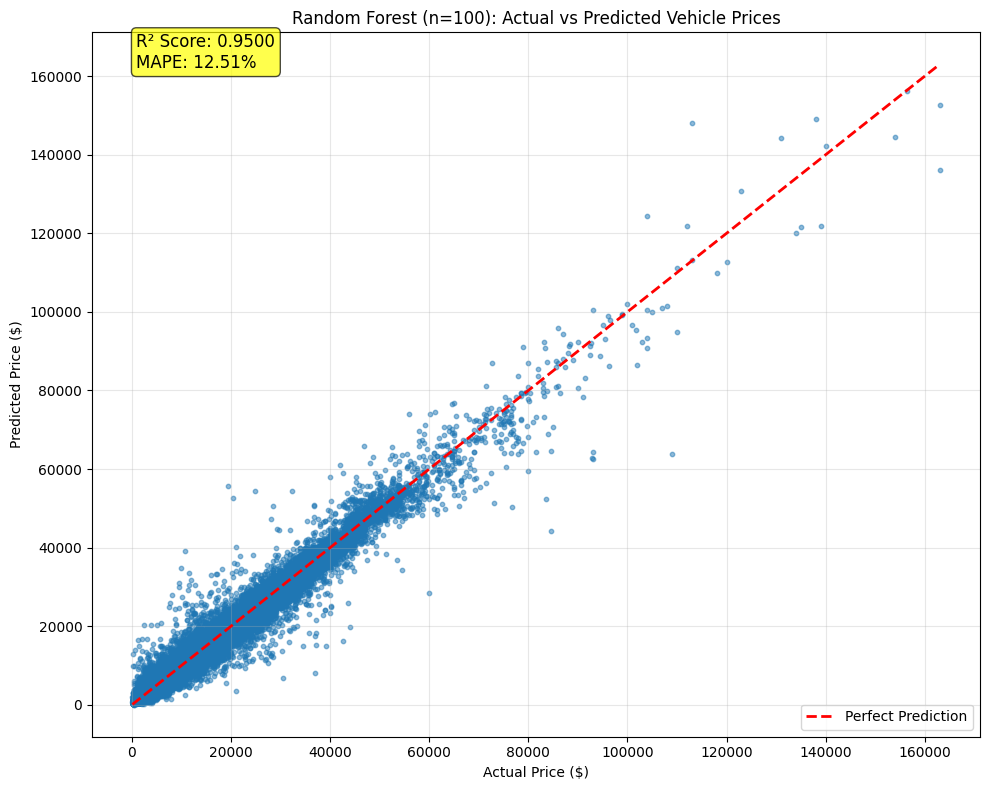

 Plot saved to: /kaggle/working/results/actual_vs_predicted.png


In [17]:
#  Plot Actual vs Predicted for Best Model
def inverse_transform_price(log_value):
    return np.expm1(log_value)

# Map model names to model objects (USE EXACT NAMES from results_df)
models_map = {
    'Random Forest (n=100)': model_rf,
    'Decision Tree (max_depth=20)': model_dt,
    'KNN Regressor (k=5)': model_knn,
    'Bayesian Ridge': model_br,
    'Ridge Regression (alpha=1.0)': model_ridge,
    'Linear Regression': model_lr,
    'ElasticNet (alpha=1.0)': model_en,
    'Lasso Regression (alpha=1.0)': model_lasso
}

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model_obj = models_map[best_model_name]

print(f"   Best Model: {best_model_name}")
print(f"   Test R²: {results_df.iloc[0]['Test R²']:.4f}")
print(f"   Test MAPE: {results_df.iloc[0]['Test MAPE (%)']:.2f}%")

# Get predictions
y_pred_best = best_model_obj.predict(trainer.X_test)

# Transform to actual prices
y_test_actual = inverse_transform_price(trainer.y_test)
y_pred_actual = inverse_transform_price(y_pred_best)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, s=10)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'{best_model_name}: Actual vs Predicted Vehicle Prices')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² score and MAPE
best_r2 = results_df.iloc[0]['Test R²']
best_mape = results_df.iloc[0]['Test MAPE (%)']
plt.text(0.05, 0.95, f'R² Score: {best_r2:.4f}\nMAPE: {best_mape:.2f}%', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.savefig('/kaggle/working/results/actual_vs_predicted.png', dpi=150)
plt.show()
print(" Plot saved to: /kaggle/working/results/actual_vs_predicted.png")

## **Residual Analysis**

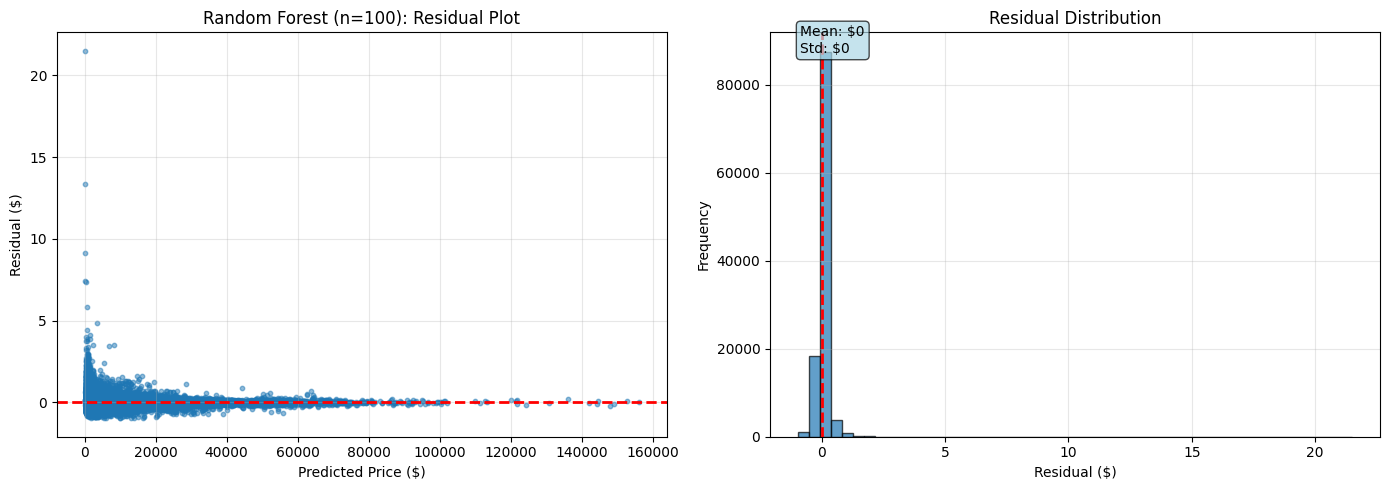

 Plot saved to: /kaggle/working/results/residual_analysis.png


In [18]:
# Cell 13: Residual analysis for best model
residuals = trainer.y_test - y_pred_best
residuals_actual = inverse_transform_price(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_actual, residuals_actual, alpha=0.5, s=10)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title(f'{best_model_name}: Residual Plot')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals_actual, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

# Add statistics
mean_residual = residuals_actual.mean()
std_residual = residuals_actual.std()
axes[1].text(0.05, 0.95, f'Mean: ${mean_residual:,.0f}\nStd: ${std_residual:,.0f}', 
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.tight_layout()
plt.savefig('/kaggle/working/results/residual_analysis.png', dpi=150)
plt.show()
print(" Plot saved to: /kaggle/working/results/residual_analysis.png")